In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import os
import pymongo
from dotenv import load_dotenv

### Connecting to MongoDb

In [ ]:
# Define the absolute path to your .env file
env_path = r"C:\Users\Harshith N\Documents\Personal_projects\Customer-segmentation-MLOps-Pipeline\credentials\mongodb.env"

# Load the variables from the specific path
load_dotenv(dotenv_path=env_path)

# Access the variables using os.getenv
CONNECTION_URL = os.getenv("CONNECTION_URL")
DB_NAME = os.getenv("DB_NAME")
COLLECTION_NAME = os.getenv("COLLECTION_NAME")

# Initialize the client
client = pymongo.MongoClient(CONNECTION_URL)
data_base = client[DB_NAME]
collection = data_base[COLLECTION_NAME]

# Verification (Optional)
print(f"Connected to database: {data_base.name}")

Connected to database: Customer-segmentation


In [55]:
df = pd.DataFrame(list(collection.find()))
df.head()

,_id,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,69f4434b7db68afaf35cb1bc,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,69f4434b7db68afaf35cb1bd,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,69f4434b7db68afaf35cb1be,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,69f4434b7db68afaf35cb1bf,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,69f4434b7db68afaf35cb1c0,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [11]:
df.shape

(5000, 13)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               5000 non-null   object 
 1   order_id          5000 non-null   int64  
 2   order_date        5000 non-null   str    
 3   customer_id       5000 non-null   int64  
 4   product_category  5000 non-null   str    
 5   region            5000 non-null   str    
 6   quantity          5000 non-null   int64  
 7   unit_price        5000 non-null   float64
 8   discount          5000 non-null   float64
 9   payment_method    5000 non-null   str    
 10  delivery_days     5000 non-null   int64  
 11  customer_rating   5000 non-null   float64
 12  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(1), str(4)
memory usage: 507.9+ KB


In [15]:
df.describe().round(1)

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0
mean,12500.5,1505.7,4.0,308.4,0.2,6.1,3.0,1022.0
std,1443.5,290.8,2.0,169.3,0.1,3.2,1.2,825.6
min,10001.0,1000.0,1.0,15.2,0.0,1.0,1.0,11.2
25%,11250.8,1253.0,2.0,161.9,0.1,3.0,2.0,354.5
50%,12500.5,1510.0,4.0,309.9,0.2,6.0,3.0,796.6
75%,13750.2,1761.0,6.0,455.6,0.3,9.0,4.0,1515.7
max,15000.0,1999.0,7.0,600.0,0.4,11.0,5.0,4119.3


### Column Classification

In [30]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: ['order_id', 'customer_id', 'quantity', 'unit_price', 'discount', 'delivery_days', 'customer_rating', 'revenue']
Categorical: ['_id', 'order_date', 'product_category', 'region', 'payment_method']


### Missing Value Analysis

In [31]:
missing_df = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": df.isnull().mean() * 100
}).sort_values(by="missing_pct", ascending=False)

print(missing_df)

                  missing_count  missing_pct
_id                           0          0.0
order_id                      0          0.0
order_date                    0          0.0
customer_id                   0          0.0
product_category              0          0.0
region                        0          0.0
quantity                      0          0.0
unit_price                    0          0.0
discount                      0          0.0
payment_method                0          0.0
delivery_days                 0          0.0
customer_rating               0          0.0
revenue                       0          0.0


### Duplicate Check

In [32]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### Column-wise Validation

order_id
- Must be unique
- Should be integer-like

In [35]:
assert df['order_id'].is_unique, "order_id is not unique"
df['order_id'] = df['order_id'].astype(str)

order_date
- Should be valid datetime
- No future dates

In [36]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Check invalid dates
print(df['order_date'].isnull().sum())

# Feature engineering
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['dayofweek'] = df['order_date'].dt.day_name()

0


customer_id

- Should be categorical (not numeric measure)
- Check cardinality

In [37]:
df['customer_id'] = df['customer_id'].astype(str)
print(df['customer_id'].nunique())

989


product_category

- Limited known categories

In [38]:
print(df['product_category'].value_counts())

df['product_category'] = df['product_category'].str.strip().str.title()

product_category
Electronics    1777
Clothing       1531
Home            969
Beauty          723
Name: count, dtype: int64


region


- Should belong to known regions

In [39]:
valid_regions = ['North', 'South', 'East', 'West']
invalid_regions = df[~df['region'].isin(valid_regions)]

print("Invalid regions:", invalid_regions.shape[0])

Invalid regions: 0


quantity

- Must be positive
- No unrealistic high values

In [41]:
print(df['quantity'].describe())

df = df[df['quantity'] > 0]


count    5000.000000
mean        4.044800
std         2.020398
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max         7.000000
Name: quantity, dtype: float64


unit_price

- Must be > 0

In [ ]:
df = df[df['unit_price'] > 0]


0

discount

- Range should be [0,1]

In [64]:
df = df[(df['discount'] >= 0) & (df['discount'] <= 1)]

payment_method

- Clean categories

In [66]:
df['payment_method'] = df['payment_method'].str.strip().str.title()
print(df['payment_method'].value_counts())

payment_method
Card      2270
Cod       1774
Wallet     956
Name: count, dtype: int64


customer_rating

- Range: 1–5

In [67]:
df = df[(df['customer_rating'] >= 1) & (df['customer_rating'] <= 5)]

revenue

- Should match formula: quantity * unit_price * (1 - discount)

In [ ]:
df['expected_revenue'] = df['quantity'] * df['unit_price'] * (1 - df['discount'])

# Check mismatch
df['revenue_diff'] = df['revenue'] - df['expected_revenue']
print(df['revenue_diff'].abs().mean())

0.0023868400000010516


### Distribution Analysis

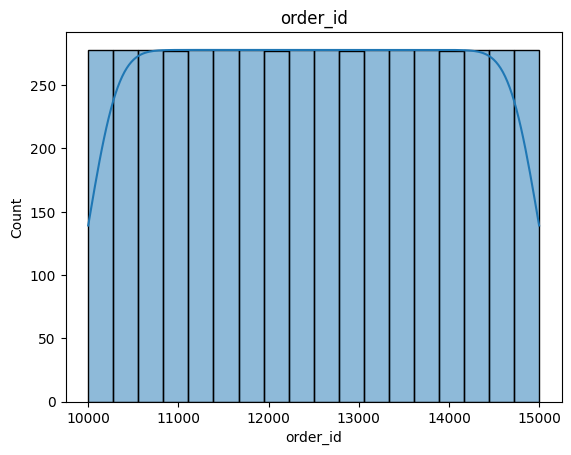

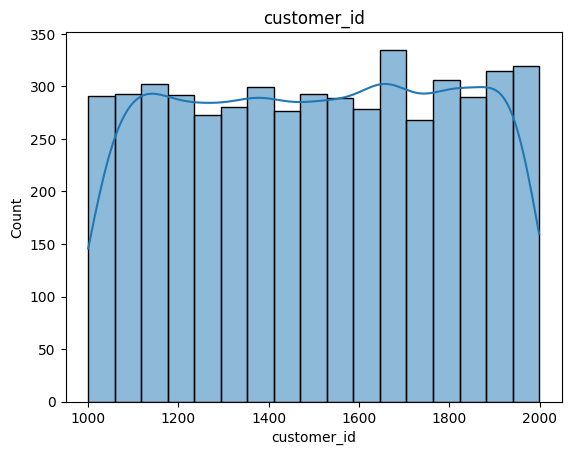

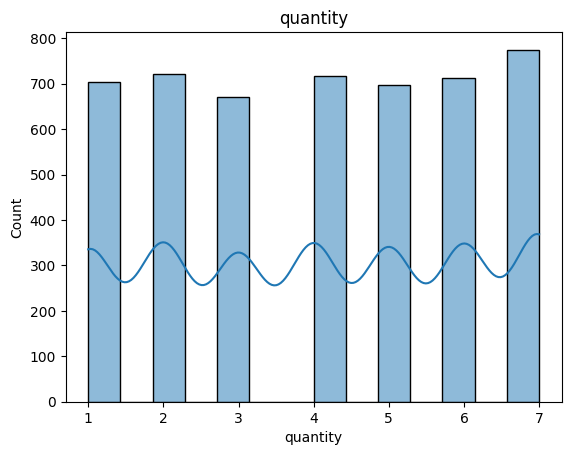

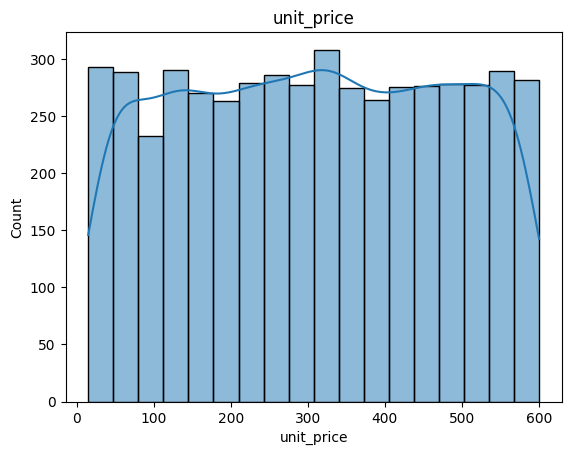

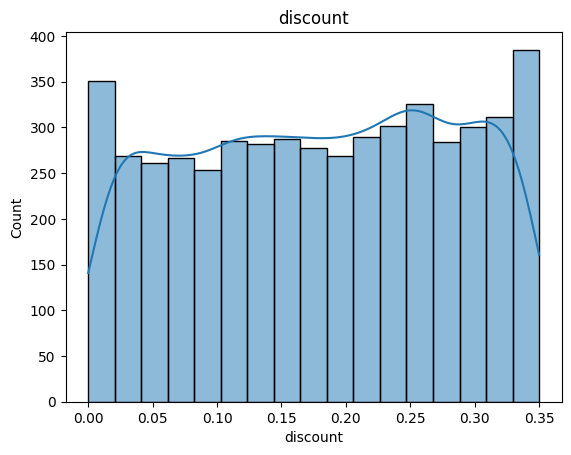

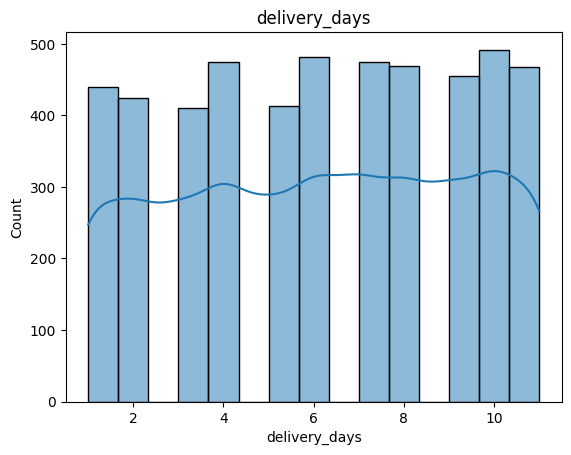

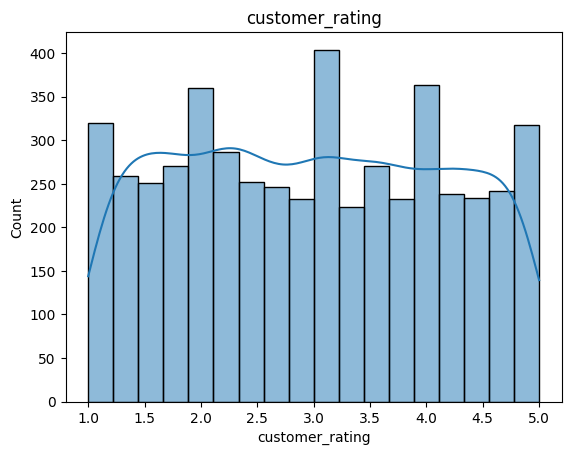

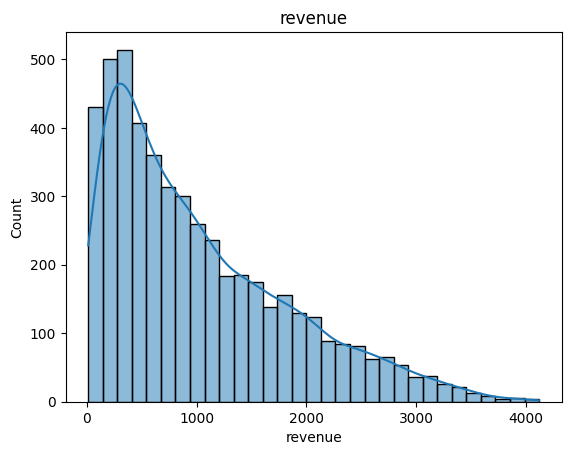

In [69]:
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

### Category vs Revenue

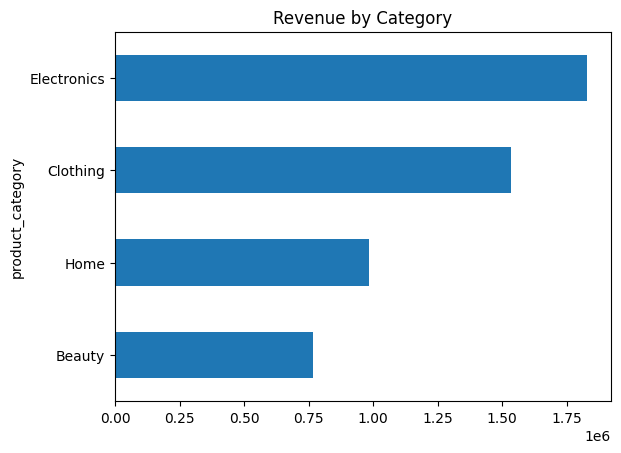

In [70]:
cat_agg = df.groupby('product_category')['revenue'].sum().sort_values()

cat_agg.plot(kind='barh', title="Revenue by Category")
plt.show()

### Time Series Trend

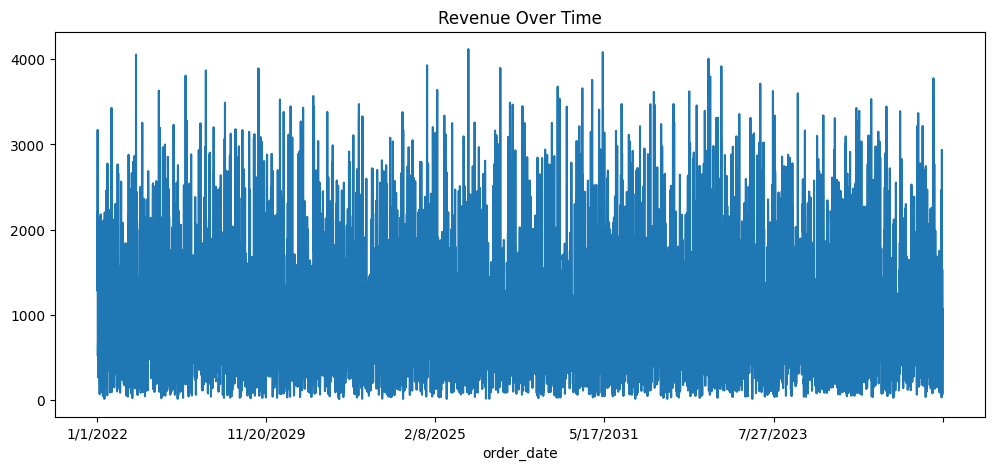

In [71]:
ts = df.groupby('order_date')['revenue'].sum()

ts.plot(figsize=(12,5), title="Revenue Over Time")
plt.show()

### Correlation Analysis

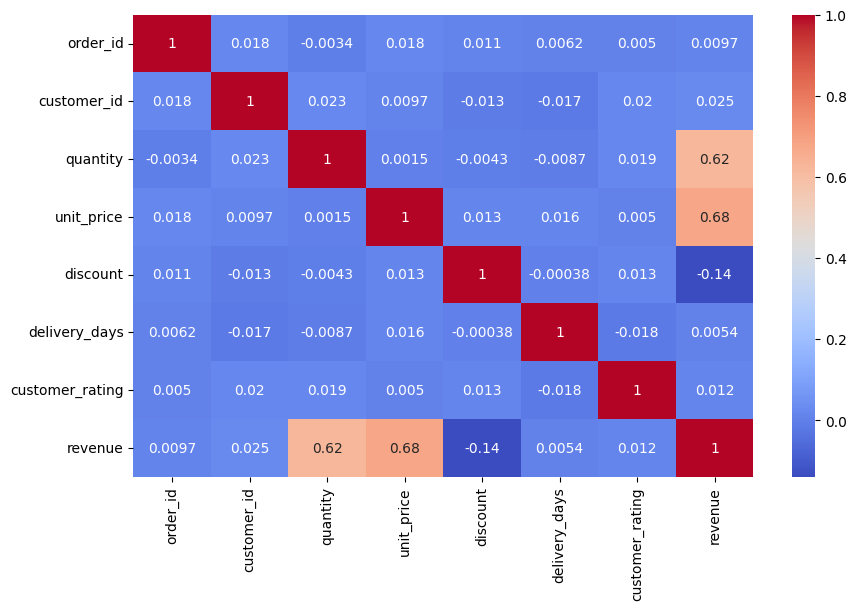

In [72]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

In [87]:
df_final = df.copy()
df_final = df_final.drop(columns=["_id"])

# print(df_final.shape)
df_final.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,expected_revenue,revenue_diff
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,1883.1960,0.0040
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,304.1038,-0.0038
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,Cod,6,2.5,644.35,644.3496,0.0004
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2569.9030,-0.0030
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,468.5645,-0.0045
